# Heart Disease Predictor (Traditional Machine Learning)

### 1) Import Libraries

In [1]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"


#----- Tools, visualizers -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import skewness_detector, outlier_detector
import joblib

#----- Preprocessing -----
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

#----- Models -----
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, \
AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.svm import SVC


### 2) Load Data

In [2]:
# Load dataset
#---------------
data = pd.read_csv(DATA_DIR / "heart-data.csv")
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


### 3) Split Data
Before preprocessing and model training, we need to split the dataset into **train** and **validation** sets.  
- The **training set** is used to learn the patterns.  
- The **validation set** is used to evaluate performance on unseen data, preventing overfitting.  

In [3]:
# Split dataset into train and validation sets
#----------------------------------------------

# Set random state
RANDOM_STATE = 42

# Separate features and labels cols
X = data.drop(columns='HeartDisease') # Features
y = data['HeartDisease'] # Labels

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15 , random_state=RANDOM_STATE, stratify=y
)

print("----Done----")

----Done----


### Preprocessing
Preprocessing ensures that the dataset is clean, consistent, and suitable for machine learning models.  
In this project, our preprocessing will focus on:  
1. **Handling invalid values**  
   - *RestingBP*: drop rows with 0 (impossible value).  
   - *OldPeak*: replace negative values with 0 (invalid in medical context).  
   - *Cholesterol*: treat 0 as missing values and impute instead of dropping (since there are many).  

2. **Imputation**  
   - For *Cholesterol*, we will impute missing/invalid values.  
   - Options: Mean, Median, or Model-based imputation.  
   - For this project, we will start simple (Median/Mean) then we can test Model-based imputations to compare performance.  

3. **Scaling / Standardization**  
   - Many ML models (e.g., Logistic Regression, SVM, KNN) require features to be on similar scales.  
   - We will apply **StandardScaler** or **MinMaxScaler** depending on the model.  

4. **Encoding categorical features**  
   - Convert categorical variables into numeric form using **One-Hot Encoding** or **Label Encoding** depending on the situation.  

5. *(Optional)* Handling skewness and outliers  
   - For this project, we will skip skewness/outlier handling, since:  
     - Skewness may only affect specific models.  
     - Outliers in medical datasets may represent real patients and should not always be removed.  

After preprocessing, the dataset will be ready to feed into our **Benchmarking Stage** where we compare multiple models.  

---


### 4) Core of preprocessing and handling data
> Including 3-5 steps mentioned above.

#### - Pipeline Approach


In [4]:
"""
Three continuous numeric features were spotted having INVALID,
 IMPOSSIBLE vlues BIOLOGICLY & in terms of MEDICAL SCIENCE
 * RestingBP -> 1 case with the value 0 (since it's only one case it's better to be removed)
 * OldPeak -> 13 cases with negative values (there are atleast two ways to consider)
    - Replacing negative values with the baseline which is 0 (clipping)
    - Using median imputation
    -> First option is reasonable since number of cases is low
 * Cholesterol -> 172 cases with the value 0 (almost 20% of values)
 - Zeros can be considered as missing values and be imputed by using median/mean or Model-based techniques
============================================================================================
Continuous numeric features should be scaled and standardized
* Including Features: [Age, RestingBP, Cholesterol, MaxHR, Oldpeak]
* First option for sclaing technique could be `StandardScaler` as default
============================================================================================
Categorical features that aren't continuous numeric type should be encoded to
numerical types.
* Including Features: [Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope]
* `FastingBS` was excluded since it's already numeric (binary: 0s 1s), but should be added to the pipeline.
* The encoders could be used are:
- One-Hot Encoding-> For binary categories
- One-Hot Encoding -> For nominal (no order) or Ordinal (ordered) categories
- Ordinal Encoding -> For ordinal (ordered) categories
* In our case for the features, all of encoders can be used for the corresponding categories:
- Sex, ExerciseAngina, FastingBS (Binary) => Label Encoder
- ChestPainType, RestingECG (Nominal) => One-Hot Encoder
- ST_Slope (Ordinal) => Ordinal  or One-Hot Encoding
"""

#-----------------------------------------------------------------------------
# - RestingBP invalid values handling: 
#   Because this part will change the number of rows and values 
#   if the target col SO we need to implement it outside Pipeline 
#   to not run into any problem

# - OldPeak and Cholesterol invalid values handling: 
#   OldPeak gets filtered and negative values will be replaced 
#   with zero, Cholesterol's zero values will be converted into 
#   Nan so that they all will be preprocessed consistently inside pipeline
#-----------------------------------------------------------------------------

# -----RestingBP-----
# Set masks: Keep all rows except the one that's 0
mask_t = X_train['RestingBP'] != 0
mask_v = X_val['RestingBP'] != 0

#  Train
#--------------
# Filter X_train
X_train = X_train[mask_t].reset_index(drop=True)

# Filter y_train
y_train = y_train[mask_t].reset_index(drop=True)

#  Validation
#---------------
# Filter X_val
X_val = X_val[mask_v].reset_index(drop=True)

# Filter y_val
y_val = y_val[mask_v].reset_index(drop=True)


#-----OldPeak-----
# Filter X_train
X_train['Oldpeak'] = X_train['Oldpeak'].apply(lambda x: 0 if x < 0 else x)

# Filter X_val
X_val['Oldpeak'] = X_val['Oldpeak'].apply(lambda x: 0 if x < 0 else x)

# -> Alternative: np.clip()


#-----Choleterol-----

# Convert zeros into Nan
X_train['Cholesterol'] = X_train['Cholesterol'].replace(0, np.nan)
X_val['Cholesterol'] = X_val['Cholesterol'].replace(0, np.nan)

#======================================================================================

f = X_train[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']]

# Check outliers of X_train after low-level cleaning to decide which scaler to use
# Safe zone -> outliers < 5%
df_out = outlier_detector(f)

# Check skewness of X_train after low-level cleaning
df_sk  = skewness_detector(f)

# Combine into one overview DataFrame
df_summary = pd.concat([df_out, df_sk], axis=1).reset_index(drop=True)

#======================================================================================

# Identify columns
#------------------

# Continuous numeric features
con_num_features = ['Age', 'RestingBP', 'MaxHR', 'Cholesterol', 'Oldpeak']

# Categorical features
bin_features = ['Sex', 'ExerciseAngina', 'FastingBS']
nom_features = ['ChestPainType', 'RestingECG']
ord_features = ['ST_Slope']


# Continuos numeric Pipelines
#------------------------------

# Continuous numeric Pipeline 
con_num_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical Pipelines
#------------------------------

# Binary features Pipeline
bin_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder", OrdinalEncoder())
])

# Nominal features Pipeline
nom_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe_encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Ordinal features Pipeline
ord_Pipeline = Pipeline(([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder", OrdinalEncoder(categories=[['Down', 'Flat', 'Up']]))
]))


# Combine all Pipelines to build preprocessor
preprocessor = ColumnTransformer([
    ("con_num", con_num_Pipeline, con_num_features),
    ("bin", bin_Pipeline, bin_features),
    ("nom", nom_Pipeline, nom_features), 
    ("ord", ord_Pipeline, ord_features)
], remainder="drop")


print("-----Preprocessing with pipeline done-----", end="\n\n")
print("Outlier & Skewness Summary (before scaling):")
df_summary

-----Preprocessing with pipeline done-----

Outlier & Skewness Summary (before scaling):


,Feature,N_outliers,Outlier_pct,Feature,Skewness,Skewness_Exceeding_Threshold
0,RestingBP,23,2.953,RestingBP,0.617980,False
1,Cholesterol,21,2.696,Cholesterol,1.288181,True
2,Oldpeak,12,1.540,Oldpeak,1.100429,True
3,MaxHR,1,0.128,MaxHR,0.163001,False
4,Age,0,0.000,Age,0.218176,False


### 10) Model Benchmarking 

#### - Benchmarking based on the pipeline preprocessing


In [24]:
# Initialize the models
models = {
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "ExtraTrees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "GaussianProcess": GaussianProcessClassifier()
}


# Train & Evaluate each model and store them in `results`
results = []

for name, model in models.items():
    # To use pipeline we need to add the next two lines in addition to others as well
    clf = clone(model) # Clone to fit on the fresh models not already fitted
    pipe = Pipeline([("preproc", preprocessor), ("model", clf)]) 
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    
    results.append({
        "Model": name,
        "F1_weighted": f1_score(y_val, y_pred, average='weighted', zero_division=0),
        "F1_macro": f1_score(y_val, y_pred, average='macro', zero_division=0),
        "F1_binary": f1_score(y_val, y_pred, average='binary', zero_division=0),
        "Accuracy": accuracy_score(y_val, y_pred)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by one or more metrics -> Primary metric: F1 score weighted
results_df = results_df.sort_values(by='F1_weighted', ascending=False).reset_index(drop=True)

results_df

,Model,F1_weighted,F1_macro,F1_binary,Accuracy
0,GradientBoosting,0.891218,0.890005,0.901961,0.891304
1,AdaBoost,0.884351,0.883667,0.890411,0.884058
2,ExtraTrees,0.884058,0.882852,0.894737,0.884058
3,RandomForest,0.876713,0.875339,0.888889,0.876812
4,SVC,0.876713,0.875339,0.888889,0.876812
5,KNN,0.869565,0.868209,0.881579,0.869565
6,GaussianProcess,0.862414,0.861086,0.874172,0.862319
7,LogisticRegression,0.861944,0.860197,0.877419,0.862319
8,GaussianNB,0.847931,0.846464,0.860927,0.847826
9,BernoulliNB,0.833728,0.833114,0.839161,0.833333


#### **NOTE:**
In preprocessing we use one of the approaches shown (Manual/Pipeline), which the pipeline approach is the common, standard and ideal way of preprocessing. But in this notebook the manual approach was ran.

#### The results of benchmarking (based on the manual approach)

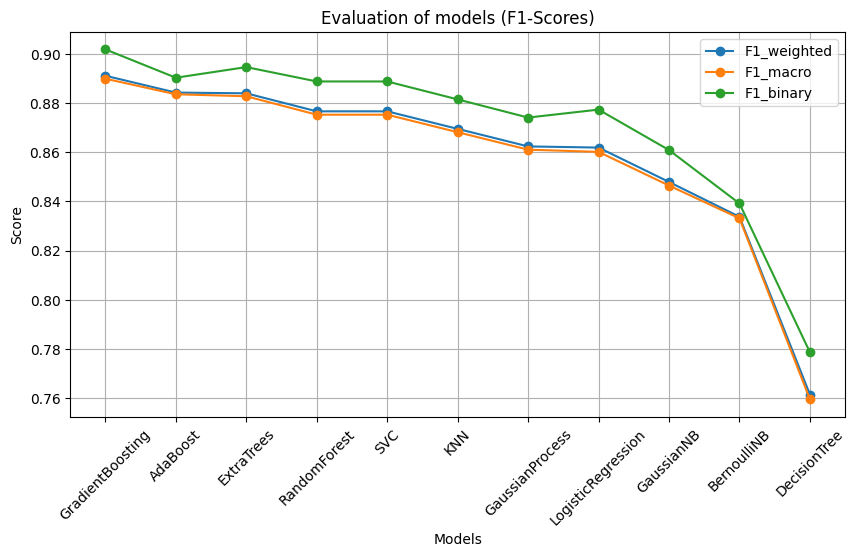

In [25]:
# Plot the benchmarking results
results_df[['F1_weighted', 'F1_macro', 'F1_binary']].plot(
    figsize=(10, 5),
    title="Evaluation of models (F1-Scores)",
    xlabel="Models",
    ylabel="Score",
    xticks=results_df.index,
    grid=True,
    marker='o'
)

# Set x-tick labels to the model names
plt.xticks(ticks=results_df.index, labels=results_df['Model'], rotation=45)
plt.show()


### Hyperparameter tuning

Although hyperparameter tuning (via GridSearchCV, RandomizedSearchCV, or Bayesian optimization) is often considered the next step after benchmarking, in this project I decided to skip it and move directly to the ensembling stage. The reasoning is as follows:

1. **Strong baseline performance:**  
   The best individual models (Random Forest, Gradient Boosting, and AdaBoost) already achieve very high F1 scores (≈0.89–0.90). These results are strong enough that hyperparameter tuning is unlikely to yield significant improvements beyond a few hundredths of a point.

2. **Risk vs. reward:**  
   Hyperparameter tuning is computationally expensive and, in some cases, may even overfit the validation set. Given the current high performance, the marginal benefit is not worth the additional cost.

3. **Ensembling advantage:**  
   Since several top models perform similarly, combining them through ensemble techniques (Voting or Stacking Classifiers) is more likely to provide a stable and possibly higher-performing solution than tuning each individual model.

For these reasons, I will move directly to the ensembling stage, where I will combine the strongest candidates to stabilize and potentially boost performance.


### 11) Build the final model

Voting Classifier:
F1-Score (weighted): 87.69 %
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86        62
           1       0.89      0.88      0.89        76

    accuracy                           0.88       138
   macro avg       0.88      0.88      0.88       138
weighted avg       0.88      0.88      0.88       138

Stacking Classifier:
F1-Score (weighted): 89.122 %
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        62
           1       0.90      0.91      0.90        76

    accuracy                           0.89       138
   macro avg       0.89      0.89      0.89       138
weighted avg       0.89      0.89      0.89       138



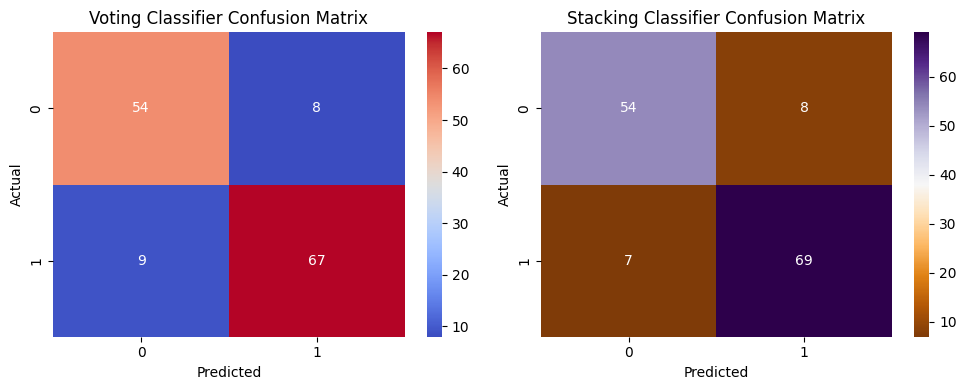

In [26]:
"""
There are multiple models with almost the same performance, 
These strong candidates can be combined to stabilize and potentially boost performance.
* Ensembeling Techniques:
- Voting Classifier
    - Equal weights are fine to start, but tuning weights can squeeze out extra performance.
- Stacking Classifier
    - If base models are diverse & strong, a simple meta-model like LogisticRegression is often best.
    - If they're weak or very different, a more flexible meta-model (like GradientBoosting) might help.
"""

# ----- Voting Classifier -----

voting_pipe = Pipeline([
    ("preproc", preprocessor),
    ("model", VotingClassifier(
        estimators=[
            ("RF", RandomForestClassifier(random_state=RANDOM_STATE)),
            ("GB", GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ("ADA", AdaBoostClassifier(random_state=RANDOM_STATE))
        ],
        voting="soft", weights=[1, 1, 1]
    ))
])

# Fit
voting_pipe.fit(X_train, y_train)
# Predict
voting_y_pred = voting_pipe.predict(X_val)

#----- Evaluate -----
print("Voting Classifier:")
# F1-score
print(f"F1-Score (weighted): {round(f1_score(y_val, voting_y_pred, average='weighted') * 100, 3)} %")
# Classification report
print(f"Classification Report:\n{classification_report(y_val, voting_y_pred)}")
# Confusion matrix
voting_cm = confusion_matrix(y_val, voting_y_pred)



# ----- Stacking Classifier -----

stacking_pipe = Pipeline([
    ("preproc", preprocessor),
    ("model", StackingClassifier(
        estimators=[
            ("RF", RandomForestClassifier(random_state=RANDOM_STATE)),
            ("GB", GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ("ADA", AdaBoostClassifier(random_state=RANDOM_STATE)),
            ("ET", ExtraTreesClassifier(random_state=RANDOM_STATE)),
            ("SVC", SVC(probability=True, random_state=RANDOM_STATE))
        ],
        final_estimator= LogisticRegression(max_iter=1000,random_state=RANDOM_STATE)
    ))
])

# Fit
stacking_pipe.fit(X_train, y_train)
# Predict
stacking_y_pred = stacking_pipe.predict(X_val)

#----- Evaluate -----
print("Stacking Classifier:")
# F1-score
print(f"F1-Score (weighted): {round(f1_score(y_val, stacking_y_pred, average='weighted') * 100, 3)} %")
# Classification report
print(f"Classification Report:\n{classification_report(y_val, stacking_y_pred)}")
# Confusion matrix
stacking_cm = confusion_matrix(y_val, stacking_y_pred)


#----- Visualize confusion matrix -----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Visualize voting classifier
sns.heatmap(voting_cm, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Voting Classifier Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# Visualize stacking classifier
sns.heatmap(stacking_cm, annot=True, cmap='PuOr', ax=axes[1])
axes[1].set_title("Stacking Classifier Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")


plt.tight_layout()
plt.show()


In [ ]:
#--------------------------------------------
# Save the model & preprocessing pipeline
#--------------------------------------------

joblib.dump(stacking_pipe, PROJECT_ROOT / "Models/Classification/stacking_model.pkl")

print("Model Saved: stacking_model.pkl")

Model Saved: stacking_model.pkl
